# SARS-CoV-2 CT Classification — Complete Reproducible Study (all-in-one)

This single notebook reproduces **every table and figure** of the manuscript comparing the prototype-based
**xDNN** classifier with **ViT**, **Swin**, **ConvNeXt** and their ensemble, including **external validation
on two independent datasets** and a **failure analysis**.

| Section | Output |
|---------|--------|
| A | xDNN baseline reproduction (validates the published F1 = 97.31%) |
| **Table 1** | Single-split performance |
| **Table 2** | 5-fold cross-validation (resumable) |
| **Table 3** | McNemar pairwise significance |
| **Table 4** | External validation — UCSD COVID-CT |
| **Table 5** | External validation — MosMedData (volume-level) |
| **Figure 1** | Experimental framework diagram |
| **Figure 2** | ViT Grad-CAM + attention rollout |
| **Figure 3** | xDNN prototypes |
| **Figures 4–6** | Failure analysis (confusion matrices, t-SNE, Grad-CAM on UCSD) |

## How to run
1. **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**.
2. When prompted in Section 1, upload your `kaggle.json` (Kaggle → Account → *Create New API Token*).
3. Read top-to-bottom: Sections **1–5** (setup, data, utilities, external loaders) **must run first**;
   afterwards each table/figure section is self-contained and reuses cached models.

## Runtime
The three deep models are trained **once** (Section 7) and reused by Tables 1, 3, 4, 5 and Figures 2, 4–6.
The only heavy step is **Table 2** (5-fold cross-validation, ~2–3 h with the default `*_small` models); it is
**resumable** — re-run the cell to continue after a disconnect. Everything else takes minutes.

## Datasets (downloaded automatically in Section 1)
SARS-CoV-2 CT (Kaggle) · UCSD COVID-CT (live GitHub mirror) · MosMedData (Kaggle). The original
UCSD-AI4H repository is offline, so a maintained mirror is used.

## A note on the xDNN feature source
The reproduction, Table 1 and Table 2 use the authors' **native** VGG features (~98%). Table 3 and Figure 3
use **re-extracted** torchvision VGG features on the same images, because a paired McNemar test and
image-mapped prototypes require predictions on identical samples; under this shared pipeline xDNN scores ~91%.

## 1. Setup — install dependencies and download all datasets

In [1]:
!pip -q install "timm>=1.0.0" grad-cam statsmodels scikit-learn py7zr nibabel cairosvg kaggle
from google.colab import files
print("Upload kaggle.json:")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# source: SARS-CoV-2
!kaggle datasets download -d plameneduardo/sarscov2-ctscan-dataset
!rm -rf /content/data && mkdir -p /content/data
!unzip -q sarscov2-ctscan-dataset.zip -d /content/data
!git clone --depth 1 https://github.com/Plamen-Eduardo/xDNN-SARS-CoV-2-CT-Scan.git

# external 1: UCSD COVID-CT (original UCSD-AI4H repo is offline; use a live mirror)
!rm -rf /content/COVID-CT
!git clone --depth 1 https://github.com/desaisrkr/https-github.com-UCSD-AI4H-COVID-CT.git /content/COVID-CT
import glob, zipfile, os, shutil
for zp in glob.glob('/content/COVID-CT/**/*.zip', recursive=True):
    if 'CT_COVID' in zp or 'CT_NonCOVID' in zp:
        with zipfile.ZipFile(zp) as z: z.extractall(os.path.dirname(zp))
for junk in glob.glob('/content/COVID-CT/**/__MACOSX', recursive=True):
    shutil.rmtree(junk, ignore_errors=True)

# external 2: MosMedData
!kaggle datasets download -d mathurinache/mosmeddata-chest-ct-scans-with-covid19
!rm -rf /content/mosmed && mkdir -p /content/mosmed
!unzip -q mosmeddata-chest-ct-scans-with-covid19.zip -d /content/mosmed
print("all datasets ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 7.6 MB/s eta 0:00:00
Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset
License(s): CC-BY-NC-SA-4.0
100% 230M/230M [00:02<00:00, 119MB/s]

Cloning into 'xDNN-SARS-CoV-2-CT-Scan'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 35.36 MiB | 33.12 MiB/s, done.
Cloning into '/content/COVID-CT'...
remote: Enumerating objects: 1062, done.
remote: Counting objects: 100% (1062/1062), done.
remote: Compressing objects: 100% (1049/1049), done.
remote: Total 1062 (delta 11), reused 1053 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (1062/1062), 370.49 MiB | 32.98 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (1048/1048), done.
Dataset URL: https://www.kaggle.com/datasets/mathurinache/mosmeddata-chest-ct-scans-with-covid19
Lic

## 2. The xDNN algorithm
Used unmodified except for two compatibility fixes (Minkowski `p=6` keyword; deprecated `np.int` removed).

In [2]:
%%writefile xDNN_class_softmax.py
"""
Please cite:

Angelov, P., & Soares, E. (2020). Towards explainable deep neural networks (xDNN). Neural Networks.
"""

import math
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix
from scipy.special import softmax



def xDNN(Input,Mode):
    if Mode == 'Learning':
        Images = Input['Images']
        Features = Input['Features']
        Labels = Input['Labels']
        CN = max(Labels)
        Prototypes = PrototypesIdentification(Images,Features,Labels,CN)
        Output = {}
        Output['xDNNParms'] = {}
        Output['xDNNParms']['Parameters'] = Prototypes
        MemberLabels = {}
        for i in range(0,CN+1):
           MemberLabels[i]=Input['Labels'][Input['Labels']==i]
        Output['xDNNParms']['CurrentNumberofClass']=CN+1
        Output['xDNNParms']['OriginalNumberofClass']=CN+1
        Output['xDNNParms']['MemberLabels']=MemberLabels
        return Output

    elif Mode == 'Validation':
        Params=Input['xDNNParms']
        datates=Input['Features']
        Test_Results = DecisionMaking(Params,datates)
        EstimatedLabels = Test_Results['EstimatedLabels']
        Scores = Test_Results['Scores']
        Output = {}
        Output['EstLabs'] = EstimatedLabels
        Output['Scores'] = Scores
        Output['ConfMa'] = confusion_matrix(Input['Labels'],Output['EstLabs'])
        Output['ClassAcc'] = np.sum(Output['ConfMa']*np.identity(len(Output['ConfMa'])))/len(Input['Labels'])
        return Output

def PrototypesIdentification(Image,GlobalFeature,LABEL,CL):
    data = {}
    image = {}
    label = {}
    Prototypes = {}
    for i in range(0,CL+1):
        seq = np.argwhere(LABEL==i)
        data[i]=GlobalFeature[seq,]
        image[i] = {}
        for j in range(0, len(seq)):
            image[i][j] = Image[seq[j][0]]
        label[i] = np.ones((len(seq),1))*i
    for i in range(0, CL+1):
        Prototypes[i] = xDNNclassifier(data[i],image[i])
    return Prototypes


def xDNNclassifier(Data,Image):
    L, N, W = np.shape(Data)
    radius =1 - math.cos(math.pi/6)
    data = Data.copy()
    Centre = data[0,]
    Center_power = np.power(Centre,2)
    X = np.sum(Center_power)
    Support =np.array([1])
    Noc = 1
    GMean = Centre.copy()
    Radius = np.array([radius])
    ND = 1
    VisualPrototype = {}
    VisualPrototype[1] = Image[0]
    for i in range(2,L+1):
        GMean = (i-1)/i*GMean+data[i-1,]/i
        CentreDensity=np.sum((Centre-np.kron(np.ones((Noc,1)),GMean))**2,axis=1)
        CDmax=max(CentreDensity)
        CDmin=min(CentreDensity)
        DataDensity=np.sum((data[i-1,] - GMean) ** 2)
        if i == 2:
            distance = cdist(data[i-1,].reshape(1,-1),Centre.reshape(1,-1),'euclidean')[0]
        else:
            distance = cdist(data[i-1,].reshape(1,-1),Centre,'euclidean')[0]
        value,position= distance.max(0),distance.argmax(0)
        value=value**2

        if DataDensity > CDmax or DataDensity < CDmin or value > 2*Radius[position]:
            Centre=np.vstack((Centre,data[i-1,]))
            Noc=Noc+1
            VisualPrototype[Noc]=Image[i-1]
            X=np.vstack((X,ND))
            Support=np.vstack((Support, 1))
            Radius=np.vstack((Radius, radius))
        else:
            Centre[position,] = Centre[position,]*(Support[position]/Support[position]+1)+data[i-1]/(Support[position]+1)
            Support[position]=Support[position]+1
            Radius[position]=0.5*Radius[position]+0.5*(X[position,]-sum(Centre[position,]**2))/2
    dic = {}
    dic['Noc'] =  Noc
    dic['Centre'] =  Centre
    dic['Support'] =  Support
    dic['Radius'] =  Radius
    dic['GMean'] =  GMean
    dic['Prototype'] = VisualPrototype
    dic['L'] =  L
    dic['X'] =  X
    return dic



def DecisionMaking(Params,datates):
    PARAM=Params['Parameters']
    CurrentNC=Params['CurrentNumberofClass']
    LAB=Params['MemberLabels']
    VV = 1
    LTes=np.shape(datates)[0]
    EstimatedLabels = np.zeros((LTes))
    Scores=np.zeros((LTes,CurrentNC))
    for i in range(1,LTes + 1):
        data = datates[i-1,]
        R=np.zeros((VV,CurrentNC))
        Value=np.zeros((CurrentNC,1))
        for k in range(0,CurrentNC):
            distance=np.sort(cdist(data.reshape(1, -1),PARAM[k]['Centre'],'minkowski',p=6))[0]
            #distance=np.sort(cdist(data.reshape(1, -1),PARAM[k]['Centre'],'euclidean'))[0]
            Value[k]=distance[0]
        Value = softmax(-1*Value**2).T
        Scores[i-1,] = Value
        Value = Value[0]
        Value_new = np.sort(Value)[::-1]
        indx = np.argsort(Value)[::-1]
        EstimatedLabels[i-1]=indx[0]
    LABEL1=np.zeros((CurrentNC,1))


    for i in range(0,CurrentNC):
        LABEL1[i] = np.unique(LAB[i])

    EstimatedLabels = EstimatedLabels.astype(int)
    EstimatedLabels = LABEL1[EstimatedLabels]
    dic = {}
    dic['EstimatedLabels'] = EstimatedLabels
    dic['Scores'] = Scores
    return dic

###############################################################################

Writing xDNN_class_softmax.py


## 3. Configuration
`MODEL_SIZE` selects the deep-architecture variant used everywhere (`'small'` by default), keeping every
table and figure internally consistent. xDNN is unaffected by this setting.

In [3]:
import os, time, random, collections, pickle, re
import numpy as np
import torch, timm
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix)

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DEV_TYPE = 'cuda' if DEVICE == 'cuda' else 'cpu'
SEED, IMG, BATCH, LR = 42, 224, 32, 3e-5
EPOCHS, EPOCHS_CV, K = 8, 6, 5
SLICES_PER_VOLUME = 10
MODEL_SIZE = 'small'   # 'small' (default) or 'base'
MODELS = {
    'small': ['vit_small_patch16_224', 'swin_small_patch4_window7_224', 'convnext_small'],
    'base' : ['vit_base_patch16_224',  'swin_base_patch4_window7_224',  'convnext_base'],
}[MODEL_SIZE]
SHORT = {MODELS[0]: 'ViT', MODELS[1]: 'Swin', MODELS[2]: 'ConvNeXt'}
CKPT_CV = '/content/cv_ckpt.pkl'
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
print('device:', DEVICE, '| models:', MODELS)

# ---------------------------------------------------------------- figure export
# Springer/MTAP artwork requirement: 300 dpi for halftone, 600 dpi for combination
# art (halftone + lines/text). Panels here mix CT images with axis labels, so 600 dpi
# is the target. Printed width is 174 mm for full-width figures and 84 mm for
# single-column ones. The helper below picks the savefig dpi that hits that target
# without touching the layout, then verifies the result.
FIG_TARGET_DPI = 600

def save_figure(name, width_mm=174, target_dpi=FIG_TARGET_DPI, fig=None, also_pdf=True):
    import matplotlib.pyplot as plt
    from PIL import Image
    fig = fig or plt.gcf()
    target_in = width_mm / 25.4
    need_px = int(round(target_dpi * target_in))
    png = f'{name}.png'
    dpi = target_dpi * target_in / fig.get_size_inches()[0]
    w = h = 0
    for _ in range(4):
        fig.savefig(png, dpi=dpi, bbox_inches='tight', pad_inches=0.02, facecolor='white')
        w, h = Image.open(png).size
        if w >= need_px:
            break
        dpi *= need_px / w * 1.02
    if also_pdf:
        fig.savefig(f'{name}.pdf', bbox_inches='tight', pad_inches=0.02, facecolor='white')
    print(f'  {png}: {w}x{h} px = {w / target_in:.0f} dpi at {width_mm} mm '
          f'({"OK" if w >= need_px else "BELOW TARGET"})')
    return png

# ---------------------------------------------------------------- determinism
# GPU training is non-deterministic by default, so two runs of this notebook give
# slightly different numbers and a manuscript aligned to one run stops matching the
# other. These settings make repeated runs on the same GPU reproduce each other, so
# tables and figures can be regenerated later without drifting apart.
# warn_only=True keeps the run alive if an op has no deterministic implementation.
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)
print('determinism: cudnn.deterministic=True, benchmark=False, deterministic algorithms on')


device: cuda | models: ['vit_small_patch16_224', 'swin_small_patch4_window7_224', 'convnext_small']
determinism: cudnn.deterministic=True, benchmark=False, deterministic algorithms on


## 4. Source data, features, and shared utilities

In [4]:
def find_two_class_root(base):
    for root, dirs, _ in os.walk(base):
        cls = [d for d in dirs if not d.startswith('.') and not d.startswith('__')]
        if len([d for d in cls if 'covid' in d.lower()]) >= 2:
            return root
    return base
DATA_ROOT = find_two_class_root('/content/data')
base_ds   = datasets.ImageFolder(DATA_ROOT)
paths     = np.array([p for p, _ in base_ds.samples])
y_all     = np.array([y for _, y in base_ds.samples]).astype(int)
covid_idx = [i for c, i in base_ds.class_to_idx.items() if 'non' not in c.lower()][0]
noncov_idx = 1 - covid_idx
inv       = {v: k for k, v in base_ds.class_to_idx.items()}
train_idx, test_idx = train_test_split(np.arange(len(base_ds)), test_size=0.2,
                                       stratify=y_all, random_state=SEED)
y_test = y_all[test_idx]
test_iscovid = (y_test == covid_idx)

train_tf = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(), transforms.Normalize(mean, std)])
eval_tf  = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor(),
    transforms.Normalize(mean, std)])
feat_tf  = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(IMG),
    transforms.ToTensor(), transforms.Normalize(mean, std)])
def loader(idx, tf, shuffle):
    return DataLoader(Subset(datasets.ImageFolder(DATA_ROOT, transform=tf), idx),
                      batch_size=BATCH, shuffle=shuffle, num_workers=2, pin_memory=True)

def metrics(y_true, preds, score_pos, pos):
    yp = (y_true == pos).astype(int); pp = (preds == pos).astype(int)
    return dict(acc=accuracy_score(y_true, preds), prec=precision_score(yp, pp, zero_division=0),
                rec=recall_score(yp, pp, zero_division=0), f1=f1_score(yp, pp, zero_division=0),
                auc=roc_auc_score(yp, score_pos), kappa=cohen_kappa_score(y_true, preds))
def iscovid_metrics(true_covid, probs):
    pred = (probs.argmax(1) == covid_idx).astype(int); score = probs[:, covid_idx]; t = true_covid.astype(int)
    return dict(acc=accuracy_score(t, pred), prec=precision_score(t, pred, zero_division=0),
                rec=recall_score(t, pred, zero_division=0), f1=f1_score(t, pred, zero_division=0),
                auc=roc_auc_score(t, score))

def train_deep(model_name, tr, va, epochs, seed, keep_model=False):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    tl = loader(tr, train_tf, True)
    model = timm.create_model(model_name, pretrained=True, num_classes=2).to(DEVICE)
    cnt = collections.Counter(y_all[tr].tolist())
    w = torch.tensor([1.0/cnt[i] for i in range(2)], dtype=torch.float); w = w/w.sum()*2
    crit = nn.CrossEntropyLoss(weight=w.to(DEVICE), label_smoothing=0.1)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
    for ep in range(epochs):
        model.train()
        for x, yb in tl:
            x, yb = x.to(DEVICE), yb.to(DEVICE); opt.zero_grad()
            with torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
                loss = crit(model(x), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sch.step()
    P = predict_probs(model, loader(va, eval_tf, False))
    if keep_model: return P, model
    del model; torch.cuda.empty_cache(); return P

def predict_probs(model, dl):
    model.eval(); out = []
    with torch.no_grad():
        for x, _ in dl:
            x = x.to(DEVICE)
            with torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
                o = model(x) + model(torch.flip(x, dims=[3]))
            out.append(torch.softmax(o.float(), 1).cpu().numpy())
    return np.concatenate(out)

MODEL_CACHE = {}
def fit_on_split(name):
    if name not in MODEL_CACHE:
        print(f'training {SHORT[name]} on the 80/20 split (cached for reuse) ...')
        P, m = train_deep(name, train_idx, test_idx, EPOCHS, SEED, keep_model=True)
        MODEL_CACHE[name] = {'probs': P, 'model': m}
        print(f'  {SHORT[name]} in-domain accuracy {(P.argmax(1)==y_test).mean()*100:.2f}%')
    return MODEL_CACHE[name]
print('utilities ready.')

utilities ready.


#### 4b. xDNN feature sets and runner

In [5]:
import scipy.io as sio, py7zr
from xDNN_class_softmax import xDNN
REPO = 'xDNN-SARS-CoV-2-CT-Scan'

def decode_categorical(p, n):
    m = sio.loadmat(p)
    fw = [np.array(v).ravel().astype(np.uint8) for k, v in m.items() if 'function_workspace' in k][0]
    isin = np.isin(fw, [1, 2]); i = 0
    while i < len(fw):
        if isin[i]:
            j = i
            while j < len(fw) and isin[j]: j += 1
            if j - i >= n: return fw[i:i + n].astype(int)
            i = j
        else: i += 1

with open('/tmp/ft.7z', 'wb') as out:
    for i in (1, 2, 3):
        out.write(open(f'{REPO}/featuresTrain_SARS_splitted.7z.00{i}', 'rb').read())
with py7zr.SevenZipFile('/tmp/ft.7z', 'r') as z: z.extractall('/tmp/fto')
Xtr = np.array(sio.loadmat('/tmp/fto/featuresTrain_SARS.mat')['featuresTrain'], dtype=np.float64)
Xte = np.array(sio.loadmat(f'{REPO}/featuresTest_SARS.mat')['featuresTest'], dtype=np.float64)
ctr = decode_categorical(f'{REPO}/YTrain_SARS.mat', len(Xtr))
cte = decode_categorical(f'{REPO}/YTest_SARS.mat', len(Xte))
X_native = np.vstack([Xtr, Xte]); _cc = np.concatenate([ctr, cte])
_cov = 2 if np.sum(_cc == 2) > np.sum(_cc == 1) else 1
y_native = (_cc == _cov).astype(int)
NAT_TRAIN, NAT_TEST, NAT_COVID = np.arange(len(Xtr)), np.arange(len(Xtr), len(Xtr)+len(Xte)), 1

from torchvision.models import vgg16, VGG16_Weights
class _VGGEnc(nn.Module):
    def __init__(self):
        super().__init__(); v = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        self.f, self.a = v.features, v.avgpool
        self.c = nn.Sequential(*list(v.classifier.children())[:-3])
    def forward(self, x):
        x = self.f(x); x = self.a(x); x = torch.flatten(x, 1); return self.c(x)
def vgg_features(folder_root):
    enc = _VGGEnc().eval().to(DEVICE); fe = []
    dl = DataLoader(datasets.ImageFolder(folder_root, transform=feat_tf), batch_size=64,
                    shuffle=False, num_workers=2, pin_memory=True)
    with torch.no_grad():
        for x, _ in dl:
            with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
                fe.append(enc(x.to(DEVICE)).float().cpu().numpy())
    del enc; torch.cuda.empty_cache()
    return np.concatenate(fe).astype(np.float64)
X_vgg = vgg_features(DATA_ROOT)   # torchvision VGG features, aligned with base_ds order

def run_xdnn(X, y, tr, va, covid):
    O1 = xDNN({'Images': np.arange(len(tr)), 'Features': X[tr], 'Labels': y[tr].astype(int)}, 'Learning')
    O2 = xDNN({'xDNNParms': O1['xDNNParms'], 'Images': np.arange(len(va)),
               'Features': X[va], 'Labels': y[va].astype(int)}, 'Validation')
    return np.array(O2['EstLabs']).ravel().astype(int), np.array(O2['Scores'])[:, covid], O1['xDNNParms']['Parameters']
def xdnn_cross(X_train, y_train_iscovid, X_query):
    O1 = xDNN({'Images': np.arange(len(X_train)), 'Features': X_train, 'Labels': y_train_iscovid.astype(int)}, 'Learning')
    O2 = xDNN({'xDNNParms': O1['xDNNParms'], 'Images': np.arange(len(X_query)),
               'Features': X_query, 'Labels': np.zeros(len(X_query), dtype=int)}, 'Validation')
    sc = np.array(O2['Scores']); P = np.zeros((len(X_query), 2))
    P[:, covid_idx] = sc[:, 1]; P[:, 1 - covid_idx] = sc[:, 0]; return P
print('xDNN features ready | native', X_native.shape, '| torchvision', X_vgg.shape)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 118MB/s]


xDNN features ready | native (2482, 4096) | torchvision (2481, 4096)


## 5. External datasets — UCSD COVID-CT and MosMedData

In [6]:
# UCSD COVID-CT (image level)
UCSD_ROOT = find_two_class_root('/content/COVID-CT')
ucsd_ds   = datasets.ImageFolder(UCSD_ROOT)
ucsd_covid_folder = [i for c, i in ucsd_ds.class_to_idx.items() if 'non' not in c.lower()][0]
ucsd_iscovid = np.array([y == ucsd_covid_folder for _, y in ucsd_ds.samples])
ucsd_paths   = [p for p, _ in ucsd_ds.samples]
ucsd_loader  = DataLoader(datasets.ImageFolder(UCSD_ROOT, transform=eval_tf),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('UCSD:', len(ucsd_ds), '| COVID', int(ucsd_iscovid.sum()))

# MosMedData (volume level)
import nibabel as nib
from PIL import Image
def mm_label(p):
    s = p.replace('\\', '/').lower()
    if re.search(r'ct[-_]?0', s):     return 0
    if re.search(r'ct[-_]?[1-4]', s): return 1
    return None
mm_niis = [p for p in glob.glob('/content/mosmed/**/*.nii*', recursive=True) if 'mask' not in p.lower()]
mm_volumes = [(p, mm_label(p)) for p in mm_niis]; mm_volumes = [(p, l) for p, l in mm_volumes if l is not None]
mm_vol_y = np.array([l for _, l in mm_volumes])
def mm_to_rgb(slice2d):
    lo, hi = -1350.0, 150.0
    x = np.clip((slice2d.astype(np.float32) - lo)/(hi - lo), 0, 1)
    return np.asarray(Image.fromarray((x*255).astype(np.uint8)).convert('RGB').resize((IMG, IMG)), dtype=np.uint8)
mm_slices, mm_slice_vol = [], []
for vi, (path, _) in enumerate(mm_volumes):
    try: vol = nib.load(path).get_fdata()
    except Exception: continue
    if vol.ndim != 3 or vol.shape[2] < 2: continue
    Z = vol.shape[2]; a, b = int(0.25*Z), max(int(0.75*Z), int(0.25*Z)+1)
    for z in np.linspace(a, b-1, min(SLICES_PER_VOLUME, b-a)).astype(int):
        mm_slices.append(mm_to_rgb(vol[:, :, z])); mm_slice_vol.append(vi)
mm_slices = np.stack(mm_slices); mm_slice_vol = np.array(mm_slice_vol)
print('MosMedData volumes', len(mm_volumes), '| COVID', int(mm_vol_y.sum()), '| slices', len(mm_slices))

UCSD: 746 | COVID 349
MosMedData volumes 1110 | COVID 856 | slices 11100


## 6. Part A — xDNN baseline reproduction

In [7]:
est, sc, _ = run_xdnn(X_native, y_native, NAT_TRAIN, NAT_TEST, NAT_COVID)
m = metrics(y_native[NAT_TEST], est, sc, NAT_COVID)
print('xDNN reproduction (native features): Acc %.2f | Prec %.2f | Rec %.2f | F1 %.2f | AUC %.2f' % (
    m['acc']*100, m['prec']*100, m['rec']*100, m['f1']*100, m['auc']*100))
print('(originally published: Acc 97.38, F1 97.31)')

xDNN reproduction (native features): Acc 98.39 | Prec 97.27 | Rec 99.60 | F1 98.42 | AUC 99.90
(originally published: Acc 97.38, F1 97.31)


## 7. Table 1 — single-split performance (trains the three models, cached for later sections)

In [8]:
rows, probs = {}, {}
for name in MODELS:
    P = fit_on_split(name)['probs']; probs[name] = P
    rows[SHORT[name]] = metrics(y_test, P.argmax(1), P[:, covid_idx], covid_idx)
P_ens = np.mean([probs[n] for n in MODELS], axis=0)
rows['Ensemble'] = metrics(y_test, P_ens.argmax(1), P_ens[:, covid_idx], covid_idx)
est, sc, _ = run_xdnn(X_native, y_native, NAT_TRAIN, NAT_TEST, NAT_COVID)
rows['xDNN'] = metrics(y_native[NAT_TEST], est, sc, NAT_COVID)
print(f'{"Method":10s}{"Accuracy":>10s}{"Precision":>11s}{"Recall":>9s}{"F1":>8s}{"AUC":>8s}')
for m in ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    r = rows[m]
    print(f'{m:10s}{r["acc"]*100:>10.2f}{r["prec"]*100:>11.2f}{r["rec"]*100:>9.2f}{r["f1"]*100:>8.2f}{r["auc"]*100:>8.2f}')

training ViT on the 80/20 split (cached for reuse) ...


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  ViT in-domain accuracy 96.58%
training Swin on the 80/20 split (cached for reuse) ...


...

model.safetensors: downloading bytes:           |  0.00B            

  Swin in-domain accuracy 98.19%
training ConvNeXt on the 80/20 split (cached for reuse) ...


model.safetensors: reconstructing file:   0%|          |  0.00B /  201MB            

model.safetensors: downloading bytes:           |  0.00B            

  ConvNeXt in-domain accuracy 98.59%
Method      Accuracy  Precision   Recall      F1     AUC
xDNN           98.39      97.27    99.60   98.42   99.90
ViT            96.58      98.75    94.42   96.54   99.72
Swin           98.19      98.40    98.01   98.20   99.88
ConvNeXt       98.59      98.80    98.41   98.60   99.95
Ensemble       98.99      99.20    98.80   99.00   99.88


## 8. Table 2 — stratified 5-fold cross-validation (heavy; resumable)
Re-running this cell after a disconnect continues from the last completed fold.

In [9]:
skf = StratifiedKFold(K, shuffle=True, random_state=SEED)
fold_of = np.empty(len(base_ds), dtype=int)
for f, (_, va) in enumerate(skf.split(np.arange(len(base_ds)), y_all)): fold_of[va] = f
state = pickle.load(open(CKPT_CV, 'rb')) if os.path.exists(CKPT_CV) else {'oof': {}, 'done': set()}
def _save(): pickle.dump(state, open(CKPT_CV, 'wb'))
for mi, name in enumerate(MODELS):
    state['oof'].setdefault(name, np.zeros((len(base_ds), 2)))
    for f, (tr, va) in enumerate(skf.split(np.arange(len(base_ds)), y_all)):
        if (name, f) in state['done']: continue
        t = time.time(); state['oof'][name][va] = train_deep(name, tr, va, EPOCHS_CV, SEED+mi*10+f)
        state['done'].add((name, f)); _save(); print(f'{SHORT[name]} fold {f+1}/{K} ({time.time()-t:.0f}s)')
state['oof'].setdefault('xDNN', np.zeros((len(X_native), 2)))
if 'xdnn_fold' not in state: state['xdnn_fold'] = np.empty(len(X_native), dtype=int)
for f, (tr, va) in enumerate(StratifiedKFold(K, shuffle=True, random_state=SEED).split(np.arange(len(X_native)), y_native)):
    state['xdnn_fold'][va] = f
    if ('xDNN', f) in state['done']: continue
    e, s, _ = run_xdnn(X_native, y_native, tr, va, NAT_COVID)
    P = np.zeros((len(va), 2)); P[:, NAT_COVID] = s; P[:, 1-NAT_COVID] = 1-s
    state['oof']['xDNN'][va] = P; state['done'].add(('xDNN', f)); _save(); print(f'xDNN fold {f+1}/{K}')
print('cross-validation complete.')

def fold_stats(oof, y, fold, pos):
    out = []
    for f in sorted(set(fold.tolist())):
        msk = fold == f; pr = oof[msk].argmax(1); yp = (y[msk] == pos).astype(int)
        out.append([accuracy_score(y[msk], pr), f1_score(yp, (pr==pos).astype(int), zero_division=0),
                    roc_auc_score(yp, oof[msk][:, pos]), cohen_kappa_score(y[msk], pr)])
    return np.array(out)
res = {SHORT[n]: fold_stats(state['oof'][n], y_all, fold_of, covid_idx) for n in MODELS}
res['Ensemble'] = fold_stats(np.mean([state['oof'][n] for n in MODELS], axis=0), y_all, fold_of, covid_idx)
res['xDNN'] = fold_stats(state['oof']['xDNN'], y_native, state['xdnn_fold'], NAT_COVID)
print(f'\n{"Method":10s}{"Accuracy":>16s}{"F1":>16s}{"AUC":>16s}{"Kappa":>16s}')
for m in ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    A = res[m].copy(); A[:, :3] *= 100
    print(f'{m:10s}' + ''.join(f'{A[:,i].mean():>9.2f} ± {A[:,i].std():<4.2f}' for i in range(4)))

ViT fold 1/5 (113s)
ViT fold 2/5 (113s)
ViT fold 3/5 (114s)
ViT fold 4/5 (111s)
ViT fold 5/5 (111s)
Swin fold 1/5 (163s)
Swin fold 2/5 (162s)
Swin fold 3/5 (177s)
Swin fold 4/5 (169s)
Swin fold 5/5 (166s)
ConvNeXt fold 1/5 (136s)
ConvNeXt fold 2/5 (154s)
ConvNeXt fold 3/5 (140s)
ConvNeXt fold 4/5 (138s)
ConvNeXt fold 5/5 (138s)
xDNN fold 1/5
xDNN fold 2/5
xDNN fold 3/5
xDNN fold 4/5
xDNN fold 5/5
cross-validation complete.

Method            Accuracy              F1             AUC           Kappa
xDNN          96.86 ± 0.68    96.92 ± 0.65    99.64 ± 0.14     0.94 ± 0.01
ViT           97.34 ± 0.62    97.33 ± 0.65    99.69 ± 0.12     0.95 ± 0.01
Swin          97.62 ± 0.70    97.61 ± 0.72    99.71 ± 0.14     0.95 ± 0.01
ConvNeXt      98.87 ± 0.37    98.88 ± 0.37    99.91 ± 0.06     0.98 ± 0.01
Ensemble      98.59 ± 0.40    98.59 ± 0.40    99.91 ± 0.06     0.97 ± 0.01


## 9. Table 3 — McNemar pairwise significance

In [10]:
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
preds = {SHORT[n]: fit_on_split(n)['probs'].argmax(1) for n in MODELS}
preds['Ensemble'] = np.mean([fit_on_split(n)['probs'] for n in MODELS], axis=0).argmax(1)
est, _, _ = run_xdnn(X_vgg, y_all, train_idx, test_idx, covid_idx)
preds['xDNN'] = est
order = ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']
print('Test accuracy (shared split):')
for m in order: print(f'  {m:10s} {(preds[m]==y_test).mean()*100:.2f}%')
def mc(a, b):
    ac, bc = (preds[a]==y_test), (preds[b]==y_test)
    tab = [[int((ac&bc).sum()), int((ac&~bc).sum())], [int((~ac&bc).sum()), int((~ac&~bc).sum())]]
    return mcnemar(tab, exact=(tab[0][1]+tab[1][0] < 25)).pvalue
alpha = 0.05/(len(order)*(len(order)-1)//2)
pmat = pd.DataFrame('—', index=order, columns=order)
print(f'\nBonferroni threshold = {alpha:.4f}')
for i in range(len(order)):
    for j in range(i+1, len(order)):
        p = mc(order[i], order[j]); pmat.iloc[i, j] = pmat.iloc[j, i] = f'{p:.4f}'
        print(f'  {order[i]:9s} vs {order[j]:9s}  p={p:.4f}  {"significant" if p<alpha else "n.s."}')
print('\n'); print(pmat.to_string())

Test accuracy (shared split):
  xDNN       90.74%
  ViT        96.58%
  Swin       98.19%
  ConvNeXt   98.59%
  Ensemble   98.99%

Bonferroni threshold = 0.0050
  xDNN      vs ViT        p=0.0003  significant
  xDNN      vs Swin       p=0.0000  significant
  xDNN      vs ConvNeXt   p=0.0000  significant
  xDNN      vs Ensemble   p=0.0000  significant
  ViT       vs Swin       p=0.0768  n.s.
  ViT       vs ConvNeXt   p=0.0309  n.s.
  ViT       vs Ensemble   p=0.0018  significant
  Swin      vs ConvNeXt   p=0.7266  n.s.
  Swin      vs Ensemble   p=0.1250  n.s.
  ConvNeXt  vs Ensemble   p=0.6250  n.s.


            xDNN     ViT    Swin ConvNeXt Ensemble
xDNN           —  0.0003  0.0000   0.0000   0.0000
ViT       0.0003       —  0.0768   0.0309   0.0018
Swin      0.0000  0.0768       —   0.7266   0.1250
ConvNeXt  0.0000  0.0309  0.7266        —   0.6250
Ensemble  0.0000  0.0018  0.1250   0.6250        —


### 9b. Table 3 as reported — McNemar repeated across five random seeds

The cell above runs a single seed. The manuscript reports, for each pair, how many of **five**
retrainings reach the Bonferroni-corrected threshold and the median *p* across them; that is the
analysis reproduced here. Runtime: four extra seeds x three models, roughly 25 minutes on a T4.


In [11]:
# Table 3 (as reported in the manuscript): McNemar across five random seeds
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

SEEDS = [SEED, 43, 44, 45, 46]
order = ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']
alpha = 0.05 / (len(order) * (len(order) - 1) // 2)

# xDNN is deterministic on a fixed split, so it is fitted once and reused for every seed
est_xdnn, _, _ = run_xdnn(X_vgg, y_all, train_idx, test_idx, covid_idx)

def mcnemar_p(a_ok, b_ok):
    tab = [[int(( a_ok &  b_ok).sum()), int(( a_ok & ~b_ok).sum())],
           [int((~a_ok &  b_ok).sum()), int((~a_ok & ~b_ok).sum())]]
    return mcnemar(tab, exact=(tab[0][1] + tab[1][0] < 25)).pvalue

pvals = {}
for s in SEEDS:
    print(f'--- seed {s} ---')
    P = {}
    for name in MODELS:
        P[SHORT[name]] = (fit_on_split(name)['probs'] if s == SEED
                          else train_deep(name, train_idx, test_idx, EPOCHS, s))
        print(f'  {SHORT[name]:9s} acc {(P[SHORT[name]].argmax(1) == y_test).mean() * 100:.2f}%')
    preds = {k: v.argmax(1) for k, v in P.items()}
    preds['Ensemble'] = np.mean([P[SHORT[n]] for n in MODELS], axis=0).argmax(1)
    preds['xDNN'] = est_xdnn
    ok = {m: (preds[m] == y_test) for m in order}
    for i in range(len(order)):
        for j in range(i + 1, len(order)):
            pvals.setdefault((order[i], order[j]), []).append(mcnemar_p(ok[order[i]], ok[order[j]]))

print(f'\nBonferroni threshold = {alpha:.4f}  |  {len(SEEDS)} seeds')
print(f'{"Comparison":32s}{"Significant runs":>18s}{"Median p":>11s}')
for (a, b), ps in pvals.items():
    nsig = sum(p < alpha for p in ps)
    print(f'{a + " vs " + b:32s}{f"{nsig}/{len(SEEDS)}":>18s}{np.median(ps):>11.3f}')


--- seed 42 ---
  ViT       acc 96.58%
  Swin      acc 98.19%
  ConvNeXt  acc 98.59%
--- seed 43 ---
  ViT       acc 97.18%
  Swin      acc 97.59%
  ConvNeXt  acc 99.20%
--- seed 44 ---
  ViT       acc 98.59%
  Swin      acc 96.58%
  ConvNeXt  acc 98.79%
--- seed 45 ---
  ViT       acc 98.59%
  Swin      acc 96.38%
  ConvNeXt  acc 98.99%
--- seed 46 ---
  ViT       acc 97.38%
  Swin      acc 96.38%
  ConvNeXt  acc 98.79%

Bonferroni threshold = 0.0050  |  5 seeds
Comparison                        Significant runs   Median p
xDNN vs ViT                                    5/5      0.000
xDNN vs Swin                                   5/5      0.000
xDNN vs ConvNeXt                               5/5      0.000
xDNN vs Ensemble                               5/5      0.000
ViT vs Swin                                    0/5      0.077
ViT vs ConvNeXt                                1/5      0.065
ViT vs Ensemble                                2/5      0.031
Swin vs ConvNeXt                    

## 10. Table 4 — external validation on UCSD COVID-CT (reuses cached models)

In [12]:
X_vgg_ucsd = vgg_features(UCSD_ROOT)
rows4 = {}
for name in MODELS:
    c = fit_on_split(name)
    p_in = c['probs']; p_ext = predict_probs(c['model'], ucsd_loader)
    rows4[SHORT[name]] = {'in': iscovid_metrics(test_iscovid, p_in), 'ext': iscovid_metrics(ucsd_iscovid, p_ext)}
    rows4.setdefault('_extprobs', {})[SHORT[name]] = p_ext; rows4.setdefault('_inprobs', {})[SHORT[name]] = p_in
ens_in = np.mean([rows4['_inprobs'][s] for s in SHORT.values()], axis=0)
ens_ext = np.mean([rows4['_extprobs'][s] for s in SHORT.values()], axis=0)
rows4['Ensemble'] = {'in': iscovid_metrics(test_iscovid, ens_in), 'ext': iscovid_metrics(ucsd_iscovid, ens_ext)}
yv = (y_all[train_idx] == covid_idx)
rows4['xDNN'] = {'in': iscovid_metrics(test_iscovid, xdnn_cross(X_vgg[train_idx], yv, X_vgg[test_idx])),
                 'ext': iscovid_metrics(ucsd_iscovid, xdnn_cross(X_vgg[train_idx], yv, X_vgg_ucsd))}
mcb = max(ucsd_iscovid.mean(), 1-ucsd_iscovid.mean())*100
print(f'{"Method":10s} | {"In-domain":^24s} | {"UCSD external":^24s} | {"dAcc":>6s}')
print(f'{"":10s} | {"Acc":>8s}{"F1":>8s}{"AUC":>8s} | {"Acc":>8s}{"F1":>8s}{"AUC":>8s} |')
for m in ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    a, b = rows4[m]['in'], rows4[m]['ext']
    print(f'{m:10s} | {a["acc"]*100:8.2f}{a["f1"]*100:8.2f}{a["auc"]*100:8.2f} | '
          f'{b["acc"]*100:8.2f}{b["f1"]*100:8.2f}{b["auc"]*100:8.2f} | {(a["acc"]-b["acc"])*100:6.1f}')
print(f'(UCSD majority-class baseline {mcb:.1f}%)')

Method     |        In-domain         |      UCSD external       |   dAcc
           |      Acc      F1     AUC |      Acc      F1     AUC |
xDNN       |    90.74   91.22   98.27 |    56.17   54.27   57.57 |   34.6
ViT        |    96.58   96.54   99.72 |    55.76   64.05   60.32 |   40.8
Swin       |    98.19   98.20   99.88 |    59.25   62.19   62.60 |   38.9
ConvNeXt   |    98.59   98.60   99.95 |    50.54   60.53   60.03 |   48.1
Ensemble   |    98.99   99.00   99.88 |    55.09   62.49   62.31 |   43.9
(UCSD majority-class baseline 53.2%)


## 11. Table 5 — external validation on MosMedData (volume-level, reuses cached models)

In [13]:
norm = transforms.Normalize(mean, std)
def predict_mm(model):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(mm_slices), BATCH):
            b = mm_slices[i:i+BATCH]
            x = torch.stack([norm(torch.from_numpy(s).permute(2, 0, 1).float()/255.) for s in b]).to(DEVICE)
            with torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
                o = model(x) + model(torch.flip(x, dims=[3]))
            out.append(torch.softmax(o.float(), 1).cpu().numpy())
    sp = np.concatenate(out)
    return np.array([sp[mm_slice_vol == vi][:, covid_idx].mean() for vi in range(len(mm_volumes))])
rows5, vsc = {}, {}
for name in MODELS:
    c = fit_on_split(name); vs = predict_mm(c['model']); vsc[SHORT[name]] = vs
    rows5[SHORT[name]] = {'in': iscovid_metrics(test_iscovid, c['probs']),
                          'ext': dict(acc=accuracy_score(mm_vol_y, (vs>=0.5).astype(int)),
                                      f1=f1_score(mm_vol_y, (vs>=0.5).astype(int), zero_division=0),
                                      auc=roc_auc_score(mm_vol_y, vs))}
ens_vs = np.mean([vsc[s] for s in SHORT.values()], axis=0)
rows5['Ensemble'] = {'in': iscovid_metrics(test_iscovid, np.mean([fit_on_split(n)['probs'] for n in MODELS], axis=0)),
                     'ext': dict(acc=accuracy_score(mm_vol_y, (ens_vs>=0.5).astype(int)),
                                 f1=f1_score(mm_vol_y, (ens_vs>=0.5).astype(int), zero_division=0),
                                 auc=roc_auc_score(mm_vol_y, ens_vs))}
mcb = max(mm_vol_y.mean(), 1-mm_vol_y.mean())*100
print(f'{"Method":10s}{"Acc(in)":>9s}{"AUC(in)":>9s}{"Acc(ext)":>10s}{"F1(ext)":>9s}{"AUC(ext)":>10s}')
for m in ['ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    a, b = rows5[m]['in'], rows5[m]['ext']
    print(f'{m:10s}{a["acc"]*100:>9.2f}{a["auc"]*100:>9.2f}{b["acc"]*100:>10.2f}{b["f1"]*100:>9.2f}{b["auc"]*100:>10.2f}')
print(f'(MosMedData majority-class baseline {mcb:.1f}%)')

Method      Acc(in)  AUC(in)  Acc(ext)  F1(ext)  AUC(ext)
ViT           96.58    99.72     37.66    32.82     75.40
Swin          98.19    99.88     35.95    29.25     75.84
ConvNeXt      98.59    99.95     77.03    86.98     70.43
Ensemble      98.99    99.88     55.05    60.49     77.37
(MosMedData majority-class baseline 77.1%)


### 11b. Table 5 — adding the xDNN row

Section 11 loops over `MODELS`, which holds only the three deep architectures, so xDNN is missing
from Table 5 while it is present in Table 4. That is an omission in the code, not a limitation of the
method: the only missing piece is VGG-16 features for the MosMedData slices. `vgg_features()` reads an
`ImageFolder`, but MosMedData slices live in memory as the array `mm_slices`, so an array variant is
defined here. Run this straight after Section 11.


In [14]:
# Table 5: volume-level MosMedData scores for the prototype-based model
# --- prerequisites, so this cell also runs after a kernel restart or out of order ---
_need = {'mm_slices': 'Section 5 (external datasets)',
         'mm_slice_vol': 'Section 5 (external datasets)',
         'mm_volumes': 'Section 5 (external datasets)',
         'mm_vol_y': 'Section 5 (external datasets)',
         'X_vgg': 'Section 4b (xDNN feature sets)',
         'xdnn_cross': 'Section 4b (xDNN feature sets)',
         '_VGGEnc': 'Section 4b (xDNN feature sets)',
         'rows5': 'Section 11 (Table 5)',
         'norm': 'Section 11 (Table 5)'}
_missing = [f'{k}  -> run {v}' for k, v in _need.items() if k not in globals()]
if _missing:
    raise RuntimeError('Section 11b cannot run yet. Missing from memory:\n  '
                       + '\n  '.join(_missing))
if 'yv' not in globals():                      # normally created in Section 10 (UCSD)
    yv = (y_all[train_idx] == covid_idx)
if 'vsc' not in globals():
    vsc = {}
# `mcb` is reused by both the UCSD and MosMedData cells, so recompute it here
mcb = max(mm_vol_y.mean(), 1 - mm_vol_y.mean()) * 100

def vgg_features_array(arr, batch=64):
    """VGG-16 penultimate features for slices already held in memory as an array."""
    enc = _VGGEnc().eval().to(DEVICE); out = []
    with torch.no_grad():
        for i in range(0, len(arr), batch):
            x = torch.stack([norm(torch.from_numpy(s).permute(2, 0, 1).float() / 255.)
                             for s in arr[i:i + batch]]).to(DEVICE)
            with torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
                out.append(enc(x).float().cpu().numpy())
    del enc; torch.cuda.empty_cache()
    return np.concatenate(out).astype(np.float64)

# Establish which output column of xdnn_cross means COVID before trusting any score.
# A below-chance AUC downstream is the classic symptom of getting this backwards.
P_src = xdnn_cross(X_vgg[train_idx], yv, X_vgg[test_idx])
acc1 = float(((P_src[:, 1] >= 0.5) == test_iscovid).mean())
acc0 = float(((P_src[:, 0] >= 0.5) == test_iscovid).mean())
XCOL = 1 if acc1 >= acc0 else 0
print(f'column check on the source test split: col1 {acc1*100:.2f}%, col0 {acc0*100:.2f}% '
      f'-> COVID score is column {XCOL}')

X_vgg_mm = vgg_features_array(mm_slices)
P_mm = xdnn_cross(X_vgg[train_idx], yv, X_vgg_mm)
vs_x = np.array([P_mm[mm_slice_vol == vi][:, XCOL].mean() for vi in range(len(mm_volumes))])

rows5['xDNN'] = {'in': iscovid_metrics(test_iscovid, P_src),
                 'ext': dict(acc=accuracy_score(mm_vol_y, (vs_x >= 0.5).astype(int)),
                             f1=f1_score(mm_vol_y, (vs_x >= 0.5).astype(int), zero_division=0),
                             auc=roc_auc_score(mm_vol_y, vs_x))}
vsc['xDNN'] = vs_x

print(f'\n{"Method":10s}{"Acc(in)":>9s}{"F1(in)":>9s}{"AUC(in)":>9s}'
      f'{"Acc(ext)":>10s}{"F1(ext)":>9s}{"AUC(ext)":>10s}{"dAcc":>8s}')
for m in ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    a, b = rows5[m]['in'], rows5[m]['ext']
    print(f'{m:10s}{a["acc"]*100:>9.2f}{a["f1"]*100:>9.2f}{a["auc"]*100:>9.2f}'
          f'{b["acc"]*100:>10.2f}{b["f1"]*100:>9.2f}{b["auc"]*100:>10.2f}'
          f'{(a["acc"] - b["acc"])*100:>8.1f}')
print(f'(MosMedData majority-class baseline {mcb:.1f}%)')


column check on the source test split: col1 9.26%, col0 90.74% -> COVID score is column 0

Method      Acc(in)   F1(in)  AUC(in)  Acc(ext)  F1(ext)  AUC(ext)    dAcc
xDNN          90.74    91.22    98.27     56.22    70.76     37.39    34.5
ViT           96.58    96.54    99.72     37.66    32.82     75.40    58.9
Swin          98.19    98.20    99.88     35.95    29.25     75.84    62.2
ConvNeXt      98.59    98.60    99.95     77.03    86.98     70.43    21.6
Ensemble      98.99    99.00    99.88     55.05    60.49     77.37    43.9
(MosMedData majority-class baseline 77.1%)


## 12b. Bootstrap confidence intervals for the external results

Section 4.6 of the manuscript reports 95% confidence intervals for the out-of-distribution
metrics, obtained by percentile bootstrap over the external test sets (2,000 resamples, at the
image level for UCSD COVID-CT and the volume level for MosMedData). No model is retrained: the
cached predictions from Sections 11 and 12 are resampled. Runtime is under a minute.


In [15]:
# 95% bootstrap confidence intervals for the external (out-of-distribution) metrics
import numpy as np

N_BOOT = 2000
boot_rng = np.random.default_rng(SEED)

def boot_ci(y, score_of, n_boot=N_BOOT):
    """Percentile bootstrap over the rows of an external test set.

    `score_of(idx)` must return (accuracy, auc) for the resampled row indices.
    Resamples that happen to contain a single class are skipped, since AUC is undefined there.
    """
    n = len(y)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        a, u = score_of(idx)
        accs.append(a); aucs.append(u)
    if not accs:                      # degenerate set: every resample was single-class
        return (float('nan'),) * 2, (float('nan'),) * 2, 0
    lohi = lambda v: (np.percentile(v, 2.5) * 100, np.percentile(v, 97.5) * 100)
    return lohi(np.array(accs)), lohi(np.array(aucs)), len(accs)

# --- make this cell survive a kernel restart -------------------------------------
# Sections 11 and 12 leave their predictions in memory; if they are gone, rebuild what
# can be rebuilt and say plainly what still has to be run.
_prereq = {'ucsd_iscovid': 'Section 10 (external datasets)',
           'ucsd_loader':  'Section 10 (external datasets)',
           'mm_vol_y':     'Section 10 (external datasets)',
           'MODEL_CACHE':  'Section 6 (utilities)',
           'predict_mm':   'Section 12 (Table 5)'}
_missing = [f'{k}  -> run {v}' for k, v in _prereq.items() if k not in globals()]
if _missing:
    raise RuntimeError('Section 12b cannot run yet. Missing from memory:\n  '
                       + '\n  '.join(_missing)
                       + '\n\nRunning the notebook top to bottom fixes this.')

if 'X_vgg_ucsd' not in globals():
    X_vgg_ucsd = vgg_features(UCSD_ROOT)
if 'yv' not in globals():
    yv = (y_all[train_idx] == covid_idx)
if 'rows4' not in globals() or not rows4.get('_extprobs'):
    print('rebuilding UCSD probabilities from the model cache ...')
    rows4 = {'_extprobs': {SHORT[n]: predict_probs(fit_on_split(n)['model'], ucsd_loader)
                           for n in MODELS}}
if 'ens_ext' not in globals() or ens_ext is None:
    ens_ext = np.mean([rows4['_extprobs'][s] for s in SHORT.values()], axis=0)
if 'vsc' not in globals() or not vsc:
    print('rebuilding MosMedData volume scores ...')
    vsc = {SHORT[n]: predict_mm(fit_on_split(n)['model']) for n in MODELS}
if 'ens_vs' not in globals() or ens_vs is None:
    ens_vs = np.mean([vsc[s] for s in SHORT.values()], axis=0)

# ---------------------------------------------------------------- UCSD COVID-CT
ucsd_scores = dict(rows4['_extprobs'])
ucsd_scores['Ensemble'] = ens_ext
ucsd_scores['xDNN'] = xdnn_cross(X_vgg[train_idx], yv, X_vgg_ucsd)

print(f'UCSD COVID-CT — image level, {N_BOOT} resamples, n = {len(ucsd_iscovid)}')
print(f'{"Method":10s}{"Acc (95% CI)":>22s}{"AUC (95% CI)":>22s}')
ucsd_ci = {}
for m in ['xDNN', 'ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    p = ucsd_scores[m]
    def score_of(idx, p=p):
        r = iscovid_metrics(ucsd_iscovid[idx], p[idx])
        return r['acc'], r['auc']
    (alo, ahi), (ulo, uhi), k = boot_ci(ucsd_iscovid, score_of)
    ucsd_ci[m] = (alo, ahi, ulo, uhi)
    print(f'{m:10s}{f"{alo:.1f}-{ahi:.1f}%":>22s}{f"{ulo:.1f}-{uhi:.1f}%":>22s}')

# ---------------------------------------------------------------- MosMedData
mm_scores = dict(vsc)
mm_scores['Ensemble'] = ens_vs

print(f'\\nMosMedData — volume level, {N_BOOT} resamples, n = {len(mm_vol_y)}')
print(f'{"Method":10s}{"Acc (95% CI)":>22s}{"AUC (95% CI)":>22s}')
mm_ci = {}
for m in ['ViT', 'Swin', 'ConvNeXt', 'Ensemble']:
    v = mm_scores[m]
    def score_of(idx, v=v):
        pred = (v[idx] >= 0.5).astype(int)
        return accuracy_score(mm_vol_y[idx], pred), roc_auc_score(mm_vol_y[idx], v[idx])
    (alo, ahi), (ulo, uhi), k = boot_ci(mm_vol_y, score_of)
    mm_ci[m] = (alo, ahi, ulo, uhi)
    print(f'{m:10s}{f"{alo:.1f}-{ahi:.1f}%":>22s}{f"{ulo:.1f}-{uhi:.1f}%":>22s}')

# ------------------------------------------------- the four numbers Section 4.6 needs
print('\\n--- for Section 4.6 ---')
alo = min(v[0] for v in ucsd_ci.values()); ahi = max(v[1] for v in ucsd_ci.values())
print(f'UCSD accuracy intervals span roughly {alo:.0f}-{ahi:.0f}% across all five methods')
print(f'UCSD ensemble AUC CI      : {ucsd_ci["Ensemble"][2]:.1f}-{ucsd_ci["Ensemble"][3]:.1f}%')
print(f'MosMedData ensemble AUC CI: {mm_ci["Ensemble"][2]:.1f}-{mm_ci["Ensemble"][3]:.1f}%')
print(f'MosMedData ConvNeXt accuracy CI: {mm_ci["ConvNeXt"][0]:.1f}-{mm_ci["ConvNeXt"][1]:.1f}% '
      f'(majority-class baseline {max(mm_vol_y.mean(), 1 - mm_vol_y.mean()) * 100:.1f}%)')


UCSD COVID-CT — image level, 2000 resamples, n = 746
Method              Acc (95% CI)          AUC (95% CI)
xDNN                  52.7-59.8%            53.4-61.7%
ViT                   52.1-59.2%            56.2-64.5%
Swin                  55.5-62.7%            58.5-66.3%
ConvNeXt              47.0-54.3%            55.8-64.3%
Ensemble              51.7-58.7%            58.2-66.1%
\nMosMedData — volume level, 2000 resamples, n = 1110
Method              Acc (95% CI)          AUC (95% CI)
ViT                   34.9-40.5%            72.2-78.6%
Swin                  33.3-38.9%            72.9-78.8%
ConvNeXt              74.5-79.4%            66.8-74.1%
Ensemble              52.2-57.9%            74.4-80.1%
\n--- for Section 4.6 ---
UCSD accuracy intervals span roughly 47-63% across all five methods
UCSD ensemble AUC CI      : 58.2-66.1%
MosMedData ensemble AUC CI: 74.4-80.1%
MosMedData ConvNeXt accuracy CI: 74.5-79.4% (majority-class baseline 77.1%)


## 12. Figure 1 — experimental framework diagram

  figure1_framework.png: 4110 px = 600 dpi at 174 mm (PDF companion is vector)


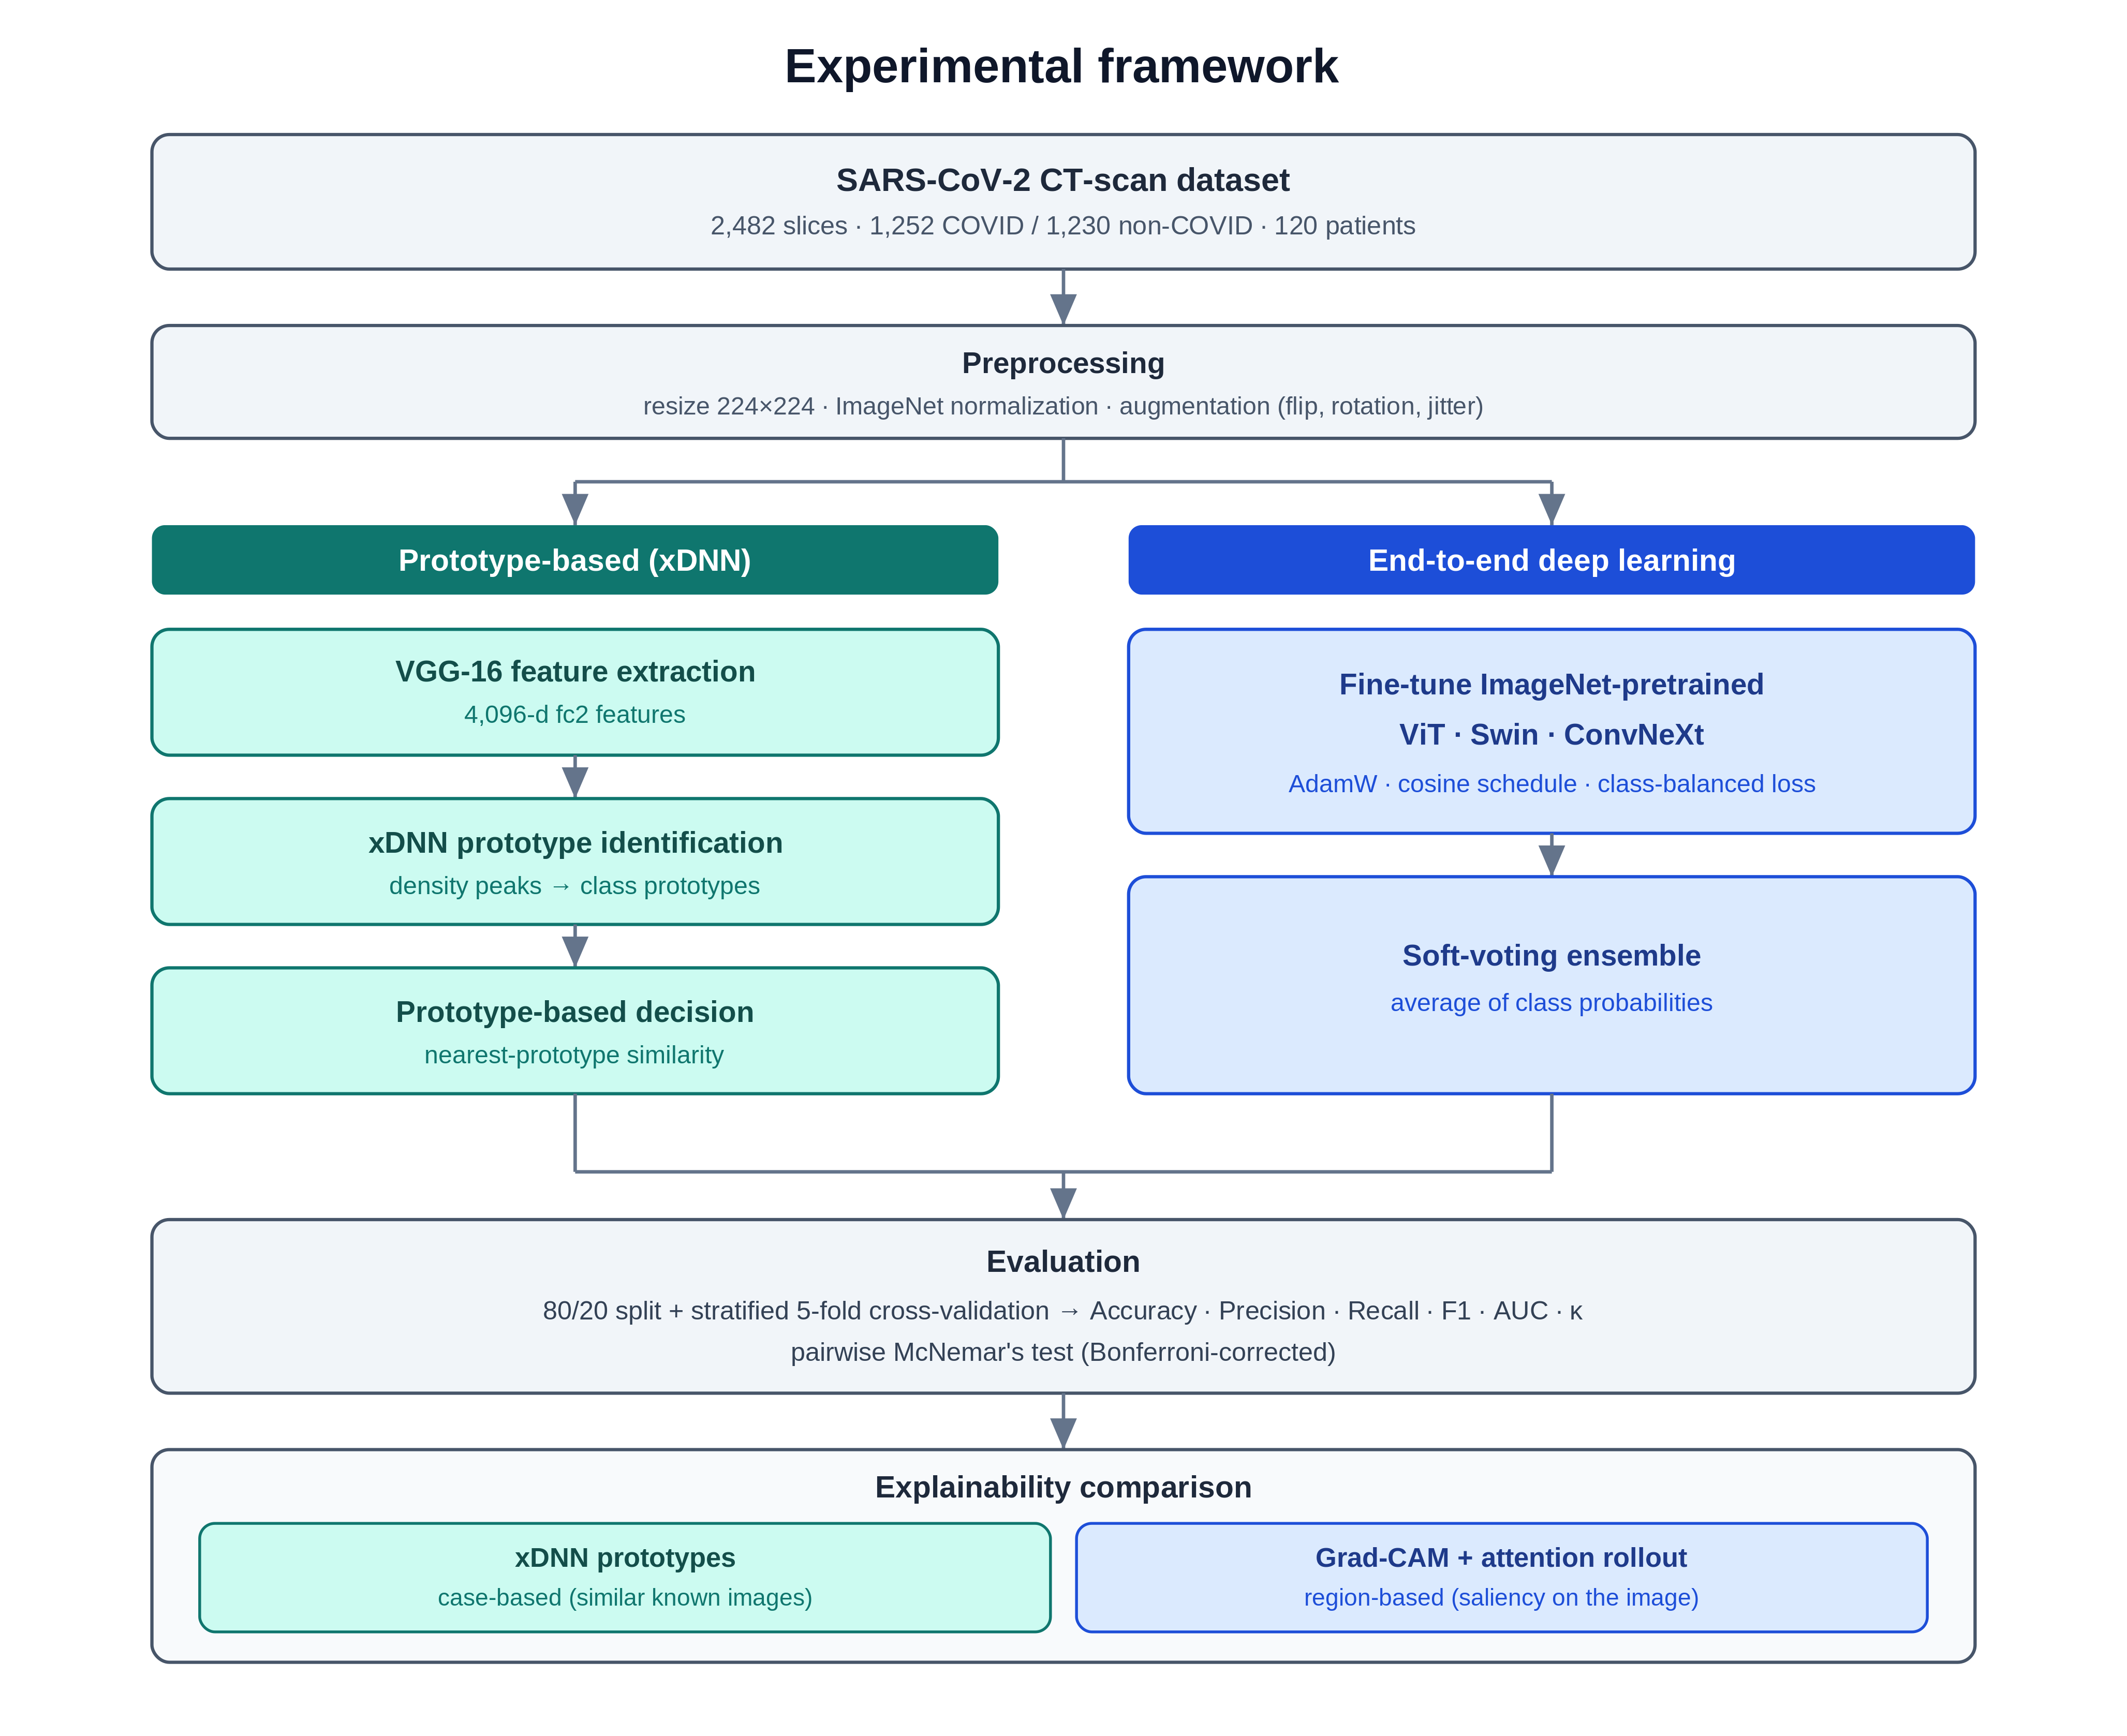

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import cairosvg
from IPython.display import Image as IPImage, display
SVG = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="800" viewBox="0 0 980 800" font-family="Helvetica, Arial, sans-serif">\n  <defs>\n    <marker id="arrow" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">\n      <path d="M0,0 L7,3 L0,6 Z" fill="#64748b"/>\n    </marker>\n  </defs>\n\n  <!-- background -->\n  <rect x="0" y="0" width="980" height="800" fill="#ffffff"/>\n\n  <!-- title -->\n  <text x="490" y="38" text-anchor="middle" font-size="22" font-weight="bold" fill="#0f172a">Experimental framework</text>\n\n  <!-- ===================== shared: input ===================== -->\n  <rect x="70" y="62" width="840" height="62" rx="8" fill="#f1f5f9" stroke="#475569" stroke-width="1.5"/>\n  <text x="490" y="88" text-anchor="middle" font-size="15" font-weight="bold" fill="#1e293b">SARS-CoV-2 CT-scan dataset</text>\n  <text x="490" y="108" text-anchor="middle" font-size="12" fill="#475569">2,482 slices · 1,252 COVID / 1,230 non-COVID · 120 patients</text>\n\n  <line x1="490" y1="124" x2="490" y2="150" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <!-- ===================== shared: preprocessing ===================== -->\n  <rect x="70" y="150" width="840" height="52" rx="8" fill="#f1f5f9" stroke="#475569" stroke-width="1.5"/>\n  <text x="490" y="172" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#1e293b">Preprocessing</text>\n  <text x="490" y="191" text-anchor="middle" font-size="11.5" fill="#475569">resize 224×224 · ImageNet normalization · augmentation (flip, rotation, jitter)</text>\n\n  <!-- split to two branches -->\n  <line x1="490" y1="202" x2="490" y2="222" stroke="#64748b" stroke-width="1.6"/>\n  <line x1="265" y1="222" x2="715" y2="222" stroke="#64748b" stroke-width="1.6"/>\n  <line x1="265" y1="222" x2="265" y2="242" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n  <line x1="715" y1="222" x2="715" y2="242" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <!-- ===================== left branch: xDNN ===================== -->\n  <rect x="70" y="242" width="390" height="32" rx="6" fill="#0f766e"/>\n  <text x="265" y="263" text-anchor="middle" font-size="14" font-weight="bold" fill="#ffffff">Prototype-based (xDNN)</text>\n\n  <rect x="70" y="290" width="390" height="58" rx="8" fill="#ccfbf1" stroke="#0f766e" stroke-width="1.5"/>\n  <text x="265" y="314" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#134e4a">VGG-16 feature extraction</text>\n  <text x="265" y="333" text-anchor="middle" font-size="11.5" fill="#0f766e">4,096-d fc2 features</text>\n\n  <line x1="265" y1="348" x2="265" y2="368" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <rect x="70" y="368" width="390" height="58" rx="8" fill="#ccfbf1" stroke="#0f766e" stroke-width="1.5"/>\n  <text x="265" y="393" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#134e4a">xDNN prototype identification</text>\n  <text x="265" y="412" text-anchor="middle" font-size="11.5" fill="#0f766e">density peaks → class prototypes</text>\n\n  <line x1="265" y1="426" x2="265" y2="446" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <rect x="70" y="446" width="390" height="58" rx="8" fill="#ccfbf1" stroke="#0f766e" stroke-width="1.5"/>\n  <text x="265" y="471" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#134e4a">Prototype-based decision</text>\n  <text x="265" y="490" text-anchor="middle" font-size="11.5" fill="#0f766e">nearest-prototype similarity</text>\n\n  <!-- ===================== right branch: deep learning ===================== -->\n  <rect x="520" y="242" width="390" height="32" rx="6" fill="#1d4ed8"/>\n  <text x="715" y="263" text-anchor="middle" font-size="14" font-weight="bold" fill="#ffffff">End-to-end deep learning</text>\n\n  <rect x="520" y="290" width="390" height="94" rx="8" fill="#dbeafe" stroke="#1d4ed8" stroke-width="1.5"/>\n  <text x="715" y="320" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#1e3a8a">Fine-tune ImageNet-pretrained</text>\n  <text x="715" y="343" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#1e3a8a">ViT · Swin · ConvNeXt</text>\n  <text x="715" y="365" text-anchor="middle" font-size="11.5" fill="#1d4ed8">AdamW · cosine schedule · class-balanced loss</text>\n\n  <line x1="715" y1="384" x2="715" y2="404" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <rect x="520" y="404" width="390" height="100" rx="8" fill="#dbeafe" stroke="#1d4ed8" stroke-width="1.5"/>\n  <text x="715" y="445" text-anchor="middle" font-size="13.5" font-weight="bold" fill="#1e3a8a">Soft-voting ensemble</text>\n  <text x="715" y="466" text-anchor="middle" font-size="11.5" fill="#1d4ed8">average of class probabilities</text>\n\n  <!-- ===================== merge ===================== -->\n  <line x1="265" y1="504" x2="265" y2="540" stroke="#64748b" stroke-width="1.6"/>\n  <line x1="715" y1="504" x2="715" y2="540" stroke="#64748b" stroke-width="1.6"/>\n  <line x1="265" y1="540" x2="715" y2="540" stroke="#64748b" stroke-width="1.6"/>\n  <line x1="490" y1="540" x2="490" y2="562" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <!-- ===================== evaluation ===================== -->\n  <rect x="70" y="562" width="840" height="80" rx="8" fill="#f1f5f9" stroke="#475569" stroke-width="1.5"/>\n  <text x="490" y="586" text-anchor="middle" font-size="14" font-weight="bold" fill="#1e293b">Evaluation</text>\n  <text x="490" y="608" text-anchor="middle" font-size="12" fill="#334155">80/20 split + stratified 5-fold cross-validation  →  Accuracy · Precision · Recall · F1 · AUC · κ</text>\n  <text x="490" y="627" text-anchor="middle" font-size="12" fill="#334155">pairwise McNemar\'s test (Bonferroni-corrected)</text>\n\n  <line x1="490" y1="642" x2="490" y2="668" stroke="#64748b" stroke-width="1.6" marker-end="url(#arrow)"/>\n\n  <!-- ===================== explainability ===================== -->\n  <rect x="70" y="668" width="840" height="98" rx="8" fill="#f8fafc" stroke="#475569" stroke-width="1.5"/>\n  <text x="490" y="690" text-anchor="middle" font-size="14" font-weight="bold" fill="#1e293b">Explainability comparison</text>\n\n  <rect x="92" y="702" width="392" height="50" rx="7" fill="#ccfbf1" stroke="#0f766e" stroke-width="1.3"/>\n  <text x="288" y="722" text-anchor="middle" font-size="12.5" font-weight="bold" fill="#134e4a">xDNN prototypes</text>\n  <text x="288" y="740" text-anchor="middle" font-size="11" fill="#0f766e">case-based (similar known images)</text>\n\n  <rect x="496" y="702" width="392" height="50" rx="7" fill="#dbeafe" stroke="#1d4ed8" stroke-width="1.3"/>\n  <text x="692" y="722" text-anchor="middle" font-size="12.5" font-weight="bold" fill="#1e3a8a">Grad-CAM + attention rollout</text>\n  <text x="692" y="740" text-anchor="middle" font-size="11" fill="#1d4ed8">region-based (saliency on the image)</text>\n</svg>\n'
open('framework.svg', 'w').write(SVG)
cairosvg.svg2png(url='framework.svg', write_to='figure1_framework.png', output_width=4110)
print('  figure1_framework.png: 4110 px = 600 dpi at 174 mm (PDF companion is vector)')
cairosvg.svg2pdf(url='framework.svg', write_to='figure1_framework.pdf')
display(IPImage('figure1_framework.png', width=720))
from google.colab import files as _f; _f.download('figure1_framework.png')

## 13. Figure 2 — ViT Grad-CAM + attention rollout (reuses the cached ViT)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  figure2_vit_explainability.png: 2021x4081 px = 611 dpi at 84 mm (OK)


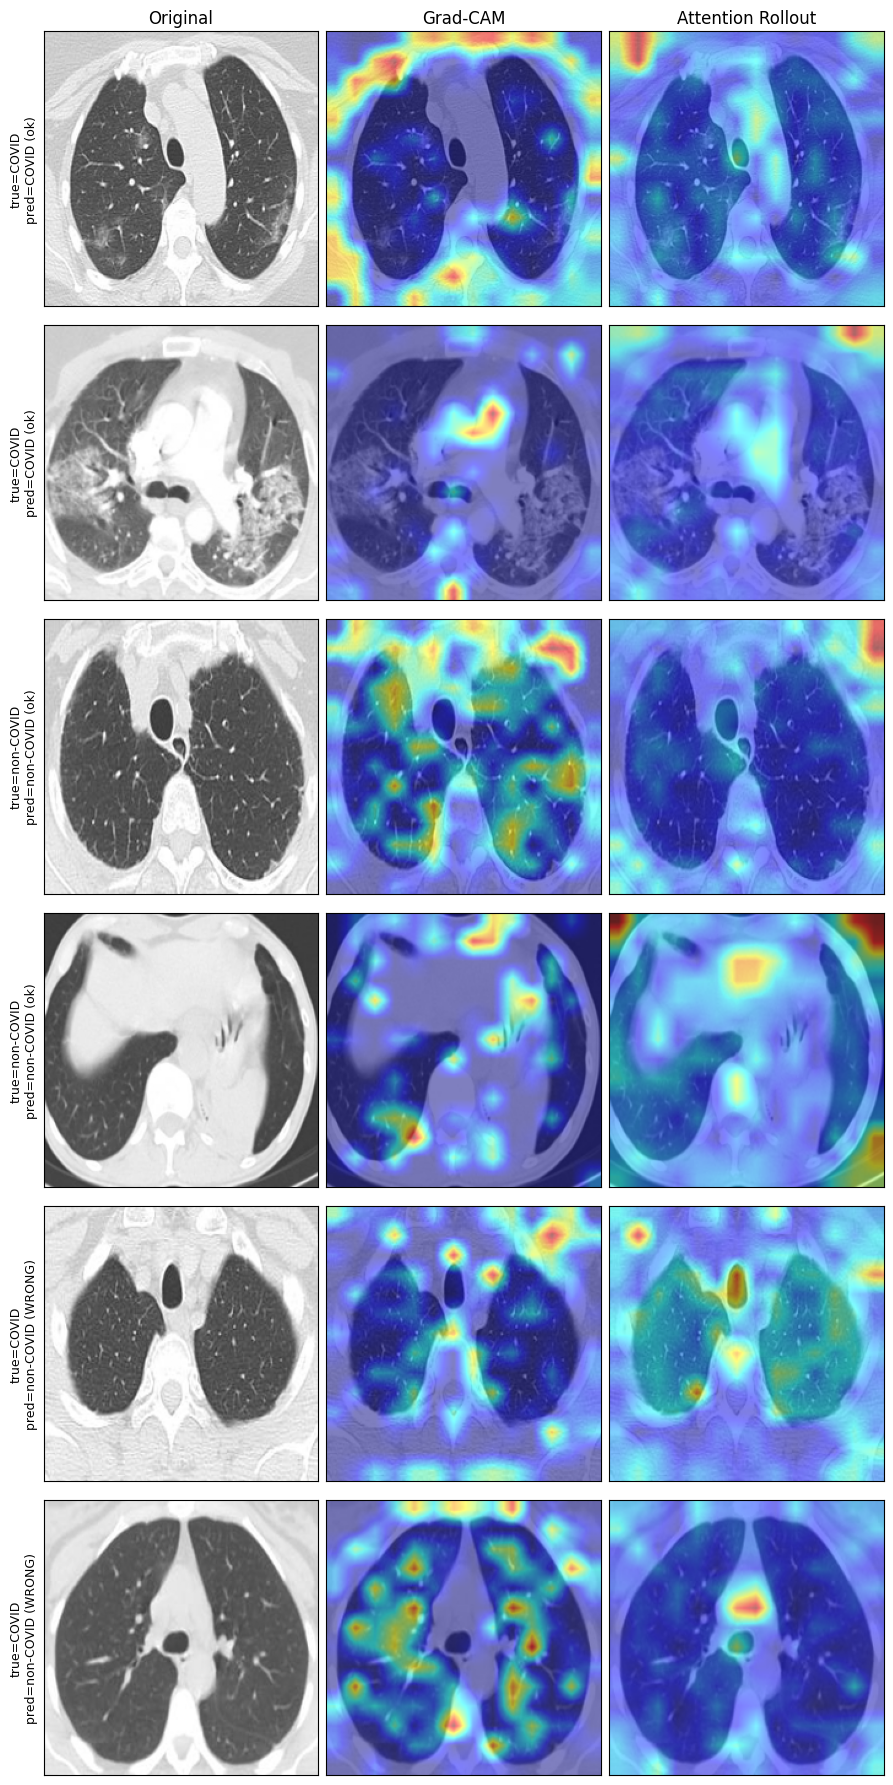

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image
import matplotlib.pyplot as plt, cv2
vit = fit_on_split(MODELS[0])['model']; vp = fit_on_split(MODELS[0])['probs'].argmax(1)
correct = test_idx[vp == y_test]; wrong = test_idx[vp != y_test]
GH, GW = vit.patch_embed.grid_size
def reshape_transform(t): return t[:, 1:, :].reshape(t.size(0), GH, GW, t.size(2)).permute(0, 3, 1, 2)
cam = GradCAM(model=vit, target_layers=[vit.blocks[-1].norm1], reshape_transform=reshape_transform)
def attn_rollout(x):
    cap, h = [], []
    for blk in vit.blocks:
        blk.attn.fused_attn = False
        h.append(blk.attn.attn_drop.register_forward_hook(lambda m, i, o: cap.append(i[0].detach())))
    vit.eval();
    with torch.no_grad(): vit(x)
    for hh in h: hh.remove()
    N = cap[0].shape[-1]; R = torch.eye(N, device=x.device)
    for a in cap:
        a = a.mean(1)[0] + torch.eye(N, device=x.device); a = a/a.sum(-1, keepdim=True); R = a @ R
    mp = R[0, 1:].reshape(GH, GW).cpu().numpy(); return (mp-mp.min())/(mp.max()-mp.min()+1e-8)
def explain(idx):
    img = Image.open(paths[idx]).convert('RGB').resize((IMG, IMG)); rgb = np.asarray(img, np.float32)/255.
    x = eval_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pred = int(vit(x).argmax(1).item())
    g = show_cam_on_image(rgb, cam(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0], use_rgb=True)
    r = show_cam_on_image(rgb, cv2.resize(attn_rollout(x), (IMG, IMG)), use_rgb=True)
    return rgb, g, r, pred
rng = np.random.RandomState(SEED)
cov = [i for i in correct if y_all[i] == covid_idx]; non = [i for i in correct if y_all[i] != covid_idx]
picks = list(rng.choice(cov, 2, replace=False)) + list(rng.choice(non, 2, replace=False)) + list(wrong[:2])
fig, ax = plt.subplots(len(picks), 3, figsize=(9, 3*len(picks)))
for r, idx in enumerate(picks):
    rgb, g, a, pred = explain(idx); tag = 'WRONG' if pred != y_all[idx] else 'ok'
    ax[r, 0].imshow(rgb); ax[r, 0].set_ylabel(f'true={inv[y_all[idx]]}\npred={inv[pred]} ({tag})', fontsize=9)
    ax[r, 1].imshow(g); ax[r, 2].imshow(a)
    for c in range(3): ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
ax[0,0].set_title('Original'); ax[0,1].set_title('Grad-CAM'); ax[0,2].set_title('Attention Rollout')
plt.tight_layout(); save_figure('figure2_vit_explainability', width_mm=84); plt.show()
from google.colab import files as _f; _f.download('figure2_vit_explainability.png')

## 14. Figure 3 — xDNN prototypes per class

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


  figure3_xdnn_prototypes.png: 4193x1498 px = 612 dpi at 174 mm (OK)


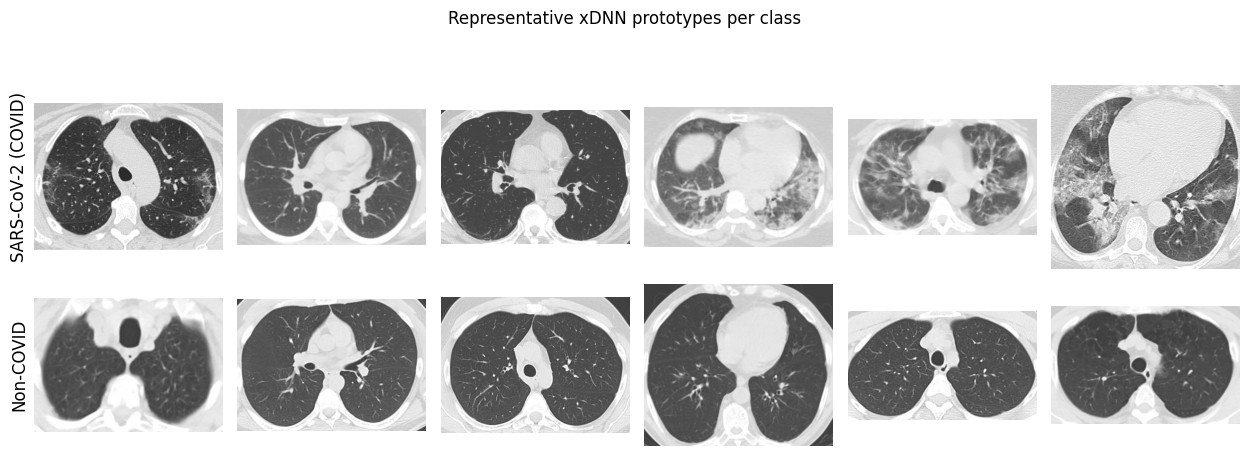

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
_, _, proto = run_xdnn(X_vgg, y_all, np.arange(len(X_vgg)), np.arange(len(X_vgg))[:1], covid_idx)
N = 6
def pick(c, n):
    pr = proto[c]['Prototype']; idxs = [int(np.array(pr[k]).ravel()[0]) for k in sorted(pr)]
    return idxs if len(idxs) <= n else [idxs[i] for i in np.linspace(0, len(idxs)-1, n).astype(int)]
rowdef = [(covid_idx, 'SARS-CoV-2 (COVID)'), (noncov_idx, 'Non-COVID')]
fig, ax = plt.subplots(2, N, figsize=(N*2.1, 2*2.4))
for r, (c, title) in enumerate(rowdef):
    sel = pick(c, N)
    for k in range(N):
        if k < len(sel): ax[r, k].imshow(Image.open(paths[sel[k]]).convert('RGB'))
        ax[r, k].axis('off')
    ax[r, 0].axis('on'); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([])
    for sp in ax[r, 0].spines.values(): sp.set_visible(False)
    ax[r, 0].set_ylabel(title, fontsize=12)
plt.suptitle('Representative xDNN prototypes per class', y=1.01); plt.tight_layout()
save_figure('figure3_xdnn_prototypes', width_mm=174); plt.show()
from google.colab import files as _f; _f.download('figure3_xdnn_prototypes.png')

## 15. Figures 4–6 — failure analysis on UCSD (confusion, t-SNE, Grad-CAM)
Explains *why* the models fail out of distribution, using the cached ViT.

  figure4_confusion.png: 4193x1832 px = 612 dpi at 174 mm (OK)


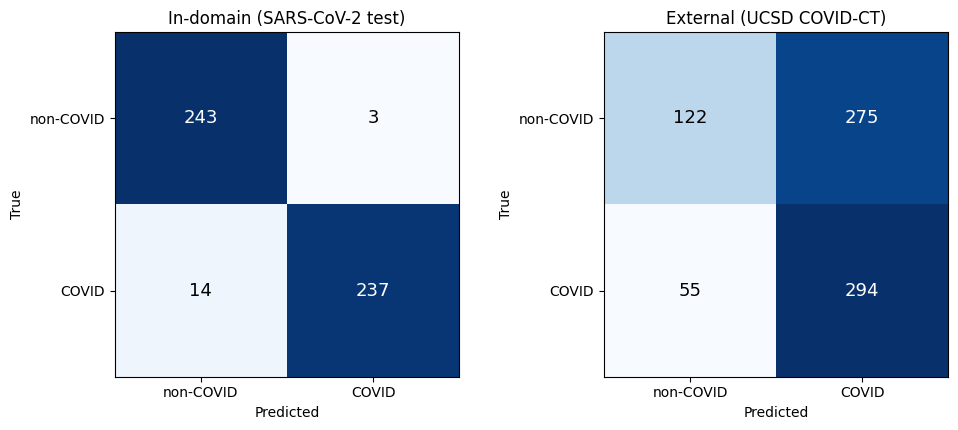

  figure5_tsne.png: 4192x3605 px = 612 dpi at 174 mm (OK)


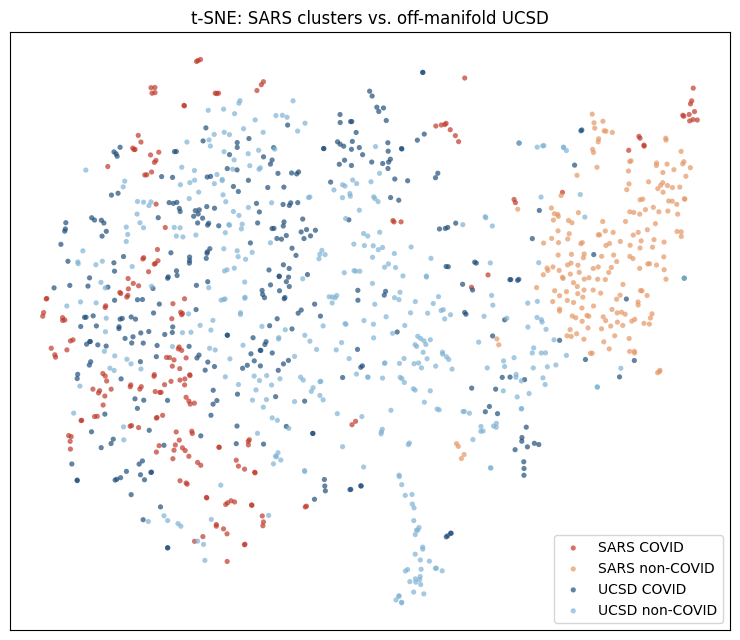

  figure6_gradcam.png: 4192x2816 px = 612 dpi at 174 mm (OK)


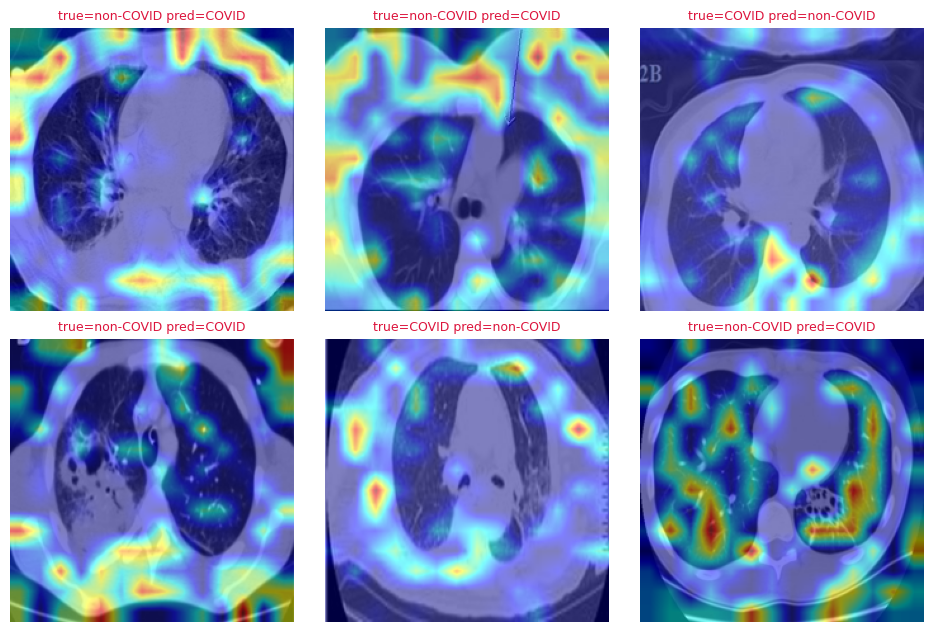

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from PIL import Image
vit = fit_on_split(MODELS[0])['model']
p_in = fit_on_split(MODELS[0])['probs']; p_ucsd = predict_probs(vit, ucsd_loader)

# Figure 4: confusion matrices
def cmx(true_covid, probs): return confusion_matrix(true_covid.astype(int), (probs.argmax(1)==covid_idx).astype(int), labels=[0,1])
labels = ['non-COVID', 'COVID']; fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for axx, (title, m) in zip(axes, [('In-domain (SARS-CoV-2 test)', cmx(test_iscovid, p_in)),
                                  ('External (UCSD COVID-CT)', cmx(ucsd_iscovid, p_ucsd))]):
    axx.imshow(m, cmap='Blues'); axx.set_title(title); axx.set_xticks([0,1]); axx.set_xticklabels(labels)
    axx.set_yticks([0,1]); axx.set_yticklabels(labels); axx.set_xlabel('Predicted'); axx.set_ylabel('True')
    for i in range(2):
        for j in range(2): axx.text(j, i, int(m[i,j]), ha='center', va='center', color='white' if m[i,j]>m.max()/2 else 'black', fontsize=13)
plt.tight_layout(); save_figure('figure4_confusion', width_mm=174); plt.show()

# Figure 5: t-SNE
def embed(dl):
    vit.eval(); E = []
    with torch.no_grad():
        for x, _ in dl:
            x = x.to(DEVICE)
            with torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
                E.append(vit.forward_head(vit.forward_features(x), pre_logits=True).float().cpu().numpy())
    return np.concatenate(E)
rng = np.random.RandomState(SEED)
sub = np.concatenate([rng.choice(np.where(y_all==covid_idx)[0], 200, False), rng.choice(np.where(y_all!=covid_idx)[0], 200, False)])
E = np.vstack([embed(loader(sub, eval_tf, False)), embed(ucsd_loader)])
emb = TSNE(2, perplexity=30, init='pca', random_state=SEED).fit_transform(E)
sic = (y_all[sub] == covid_idx)
grp = (['SARS COVID' if c else 'SARS non-COVID' for c in sic] + ['UCSD COVID' if c else 'UCSD non-COVID' for c in ucsd_iscovid])
col = {'SARS COVID':'#c0392b','SARS non-COVID':'#e59866','UCSD COVID':'#1f4e79','UCSD non-COVID':'#7fb3d5'}
plt.figure(figsize=(7.5, 6.5))
for g, c in col.items():
    msk = np.array([x==g for x in grp]); plt.scatter(emb[msk,0], emb[msk,1], s=14, alpha=0.7, c=c, label=g, edgecolors='none')
plt.legend(); plt.xticks([]); plt.yticks([]); plt.title('t-SNE: SARS clusters vs. off-manifold UCSD')
plt.tight_layout(); save_figure('figure5_tsne', width_mm=174); plt.show()

# Figure 6: Grad-CAM on misclassified UCSD
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
GH, GW = vit.patch_embed.grid_size
def rt(t): return t[:, 1:, :].reshape(t.size(0), GH, GW, t.size(2)).permute(0, 3, 1, 2)
cam = GradCAM(model=vit, target_layers=[vit.blocks[-1].norm1], reshape_transform=rt)
wrong = np.where((p_ucsd.argmax(1)==covid_idx).astype(int) != ucsd_iscovid.astype(int))[0]
picks = rng.choice(wrong, min(6, len(wrong)), replace=False); inv2 = {1:'COVID', 0:'non-COVID'}
fig, axes = plt.subplots(2, 3, figsize=(9.6, 6.4)); axes = axes.reshape(-1)
for axx, idx in zip(axes, picks):
    img = Image.open(ucsd_paths[idx]).convert('RGB').resize((IMG, IMG)); rgb = np.asarray(img, np.float32)/255.
    x = eval_tf(img).unsqueeze(0).to(DEVICE); pred = int(vit(x).argmax(1).item())
    g = show_cam_on_image(rgb, cam(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0], use_rgb=True)
    axx.imshow(g); axx.set_title(f'true={inv2[int(ucsd_iscovid[idx])]} pred={inv2[int(pred==covid_idx)]}', fontsize=9, color='crimson'); axx.axis('off')
for axx in axes[len(picks):]: axx.axis('off')
plt.tight_layout(); save_figure('figure6_gradcam', width_mm=174); plt.show()
from google.colab import files as _f
for fn in ['figure4_confusion', 'figure5_tsne', 'figure6_gradcam']:
    for ext in ('.png', '.pdf'): _f.download(fn + ext)

## 16. Table 7 — computational efficiency

Parameters, FLOPs, single-image latency, batched throughput and end-to-end training time,
measured on whatever GPU this notebook is running on. Re-measure before reporting: the numbers
in the manuscript were taken on an NVIDIA T4.


In [20]:
# Table 7: computational efficiency
!pip -q install fvcore
import time
from fvcore.nn import FlopCountAnalysis

def bench(name):
    m = fit_on_split(name)['model'].eval()
    params = sum(p.numel() for p in m.parameters()) / 1e6
    x1 = torch.randn(1, 3, IMG, IMG, device=DEVICE)
    fa = FlopCountAnalysis(m, x1)
    fa.unsupported_ops_warnings(False); fa.uncalled_modules_warnings(False)
    gflops = fa.total() / 1e9

    # match the precision used everywhere else in this notebook (Section 3.3 of the
    # manuscript states mixed precision throughout); an fp32 benchmark would understate
    # inference speed by several times on a T4.
    def per_call(x, warmup, runs):
        with torch.no_grad(), torch.amp.autocast(DEV_TYPE, enabled=(DEVICE == 'cuda')):
            for _ in range(warmup): m(x)
            if DEVICE == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(runs): m(x)
            if DEVICE == 'cuda': torch.cuda.synchronize()
        return (time.perf_counter() - t0) / runs

    latency_ms = per_call(x1, 20, 100) * 1000
    xb = torch.randn(BATCH, 3, IMG, IMG, device=DEVICE)
    throughput = BATCH / per_call(xb, 5, 20)
    return params, gflops, latency_ms, throughput

print(f'{"Method":11s}{"Params(M)":>11s}{"FLOPs(G)":>10s}{"Lat(ms)":>9s}{"img/s":>8s}{"Train(s)":>10s}')
for name in MODELS:
    pa, gf, la, th = bench(name)
    t0 = time.perf_counter()
    train_deep(name, train_idx, test_idx, EPOCHS, SEED)   # timed re-fit, result discarded
    print(f'{SHORT[name]:11s}{pa:>11.1f}{gf:>10.2f}{la:>9.1f}{th:>8.0f}{time.perf_counter() - t0:>10.0f}')

t0 = time.perf_counter()
run_xdnn(X_vgg, y_all, train_idx, test_idx, covid_idx)
print(f'{"xDNN":11s}{"n/a":>11s}{"n/a":>10s}{"n/a":>9s}{"n/a":>8s}{time.perf_counter() - t0:>10.0f}')
print('\nxDNN timing excludes the VGG-16 feature-extraction pass, which does need a GPU.')
print('fvcore does not fully count attention and GELU ops, so transformer FLOPs are under-estimates.')
print('Latency and throughput are measured under autocast, matching training and evaluation.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.7 MB/s eta 0:00:00
Method       Params(M)  FLOPs(G)  Lat(ms)   img/s  Train(s)
ViT               21.7      4.61     31.1     684       155
Swin              48.8      8.77     50.9     249       219
ConvNeXt          49.5      8.70     30.7     372       186
xDNN               n/a       n/a      n/a     n/a       133

xDNN timing excludes the VGG-16 feature-extraction pass, which does need a GPU.
fvcore does not fully count attention and GELU ops, so transformer FLOPs are under-estimates.
Latency and throughput are measured under autocast, matching training and evaluation.


## 17. Table 6 — patient-level evaluation (separate script)

Table 6 quantifies slice-level leakage on the larger, patient-organised dataset of Soares et al. [16]
(4,173 scans, 210 subjects), which is **not** downloaded by this notebook. That experiment lives in
`patient_level_evaluation.py` in the same repository, and needs the patient identifiers released with
that dataset in order to build subject-disjoint folds. Everything else (preprocessing, `train_deep`,
`metrics`) is shared with this notebook.


## Summary
Running all sections reproduces **Tables 1-5, Table 7 and Figures 1-6**, plus the multi-seed version of
Table 3 in Section 9b and the bootstrap confidence intervals for Section 4.6 in Section 12b. Table 6 (patient-level leakage) requires a second dataset and is provided as a
separate script in the repository, as described in Section 17.

Keep `MODEL_SIZE` fixed for every reported result. Copy the printed tables into the manuscript and insert
the saved figures. The heavy steps are the cross-validation (Section 8) and the five-seed analysis
(Section 9b); the former is resumable.

Every figure is exported through `save_figure()` at 600 dpi for its printed width (174 mm full width,
84 mm single column), with a vector PDF alongside each PNG. Each cell prints the achieved resolution,
so check those lines before submitting the artwork.
